# Avocado Data Analytics

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Data preparation

In [3]:
df = pd.read_csv(r"C:\Users\Tharuni\Desktop\NIT\sept month\1st_open ai\Avocado price prediction\data\avocado.csv")

In [4]:
# explore the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [5]:
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [6]:
# Dropping unnecessary columns
df = df.drop(['Unnamed: 0','4046','4225','4770','Date'],axis=1)
df.head()

,AveragePrice,Total Volume,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,1.33,64236.62,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1.35,54876.98,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,0.93,118220.22,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,1.08,78992.15,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,1.28,51039.60,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


Answering questions

In [7]:
def get_avarage(df,column):
    """
    Description: This function to return the average value of the column 

    Arguments:
        df: the DataFrame. 
        column: the selected column. 
    Returns:
        column's average 
    """
    return sum(df[column])/len(df)

In [8]:
def get_avarage_between_two_columns(df,column1,column2):
    """
    Description: This function calculate the average between two columns in the dataset

    Arguments:
        df: the DataFrame. 
        column1:the first column. 
        column2:the scond column.
    Returns:
        Sorted data for relation between column1 and column2
    """
    List = list(df[column1].unique())
    average=[]
    
    for i in List:
        x = df[df[column1]==i]
        column1_average= get_avarage(x,column2)
        average.append(column1_average)
    df_column1_column2 = pd.DataFrame({'column1':List,'column2':average})
    column1_column2_sorted_index=df_column1_column2.column2.sort_values(ascending=False).index.values
    column1_column2_sorted_data=df_column1_column2.reindex(column1_column2_sorted_index)
    
    return column1_column2_sorted_data

In [9]:
def plot(data,xlabel,ylabel):
    """
    Description: This function to draw a barplot

    Arguments:
        data: the DataFrame. 
        xlabel: the label of the first column. 
        ylabel: the label of the second column.
    Returns:
        None
    """
    plt.figure(figsize=(15,5))
    ax=sns.barplot(x=data.column1,y=data.column2,palette='rocket')
    plt.xticks(rotation=90)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(('Avarage '+ylabel+' of Avocado According to '+xlabel))
    plt.show()

C:\Users\Tharuni\AppData\Local\Temp\ipykernel_8716\1862861028.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=data.column1,y=data.column2,palette='rocket')


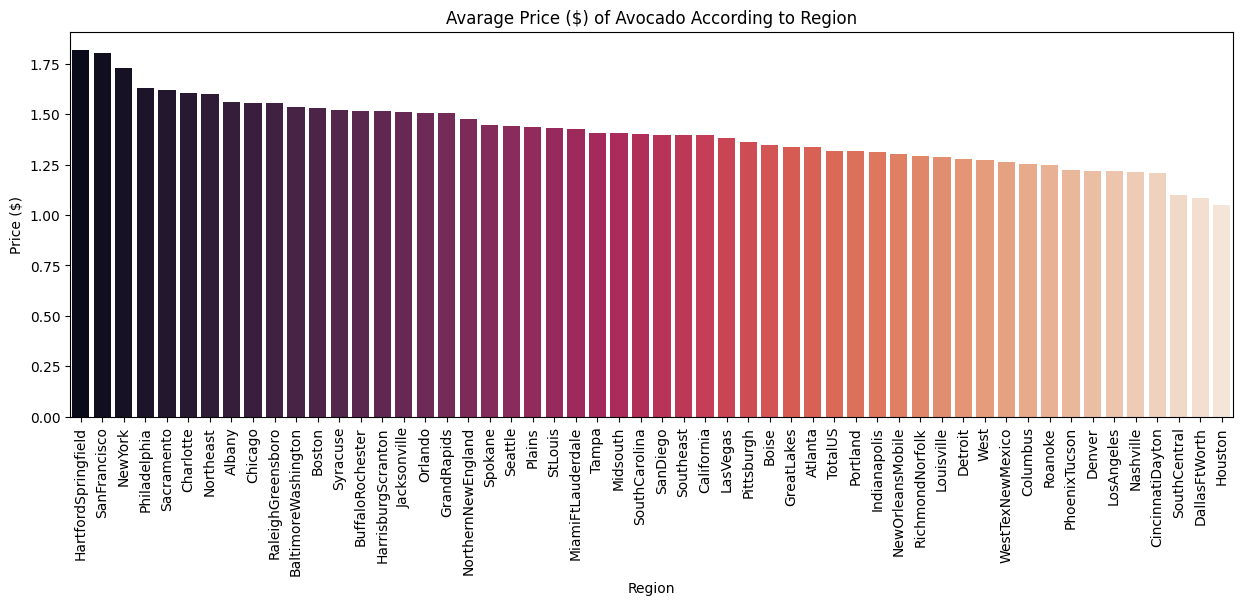

In [10]:
#Which region are the lowest and highest prices of Avocado?
data1 = get_avarage_between_two_columns(df,'region','AveragePrice')
plot(data1,'Region','Price ($)')

Text(0.5, 1.0, 'Figgure: boxplot representinf outlier columns')

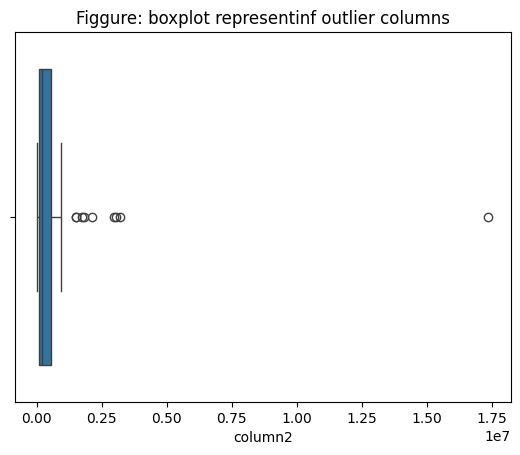

In [11]:
# What is the highest region of avocado production?
data2 = get_avarage_between_two_columns(df, 'region','Total Volume')
sns.boxplot(x=data2.column2).set_title("Figgure: boxplot representinf outlier columns")

In [12]:
outlier_region = data2[data2.column2>10000000]
print(outlier_region['column1'].iloc[-1], "is outlier value")

TotalUS is outlier value


In [14]:
# remove outlier values
outlier_region.index
data2 = data2.drop(outlier_region.index,axis=0)

C:\Users\Tharuni\AppData\Local\Temp\ipykernel_8716\1862861028.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=data.column1,y=data.column2,palette='rocket')


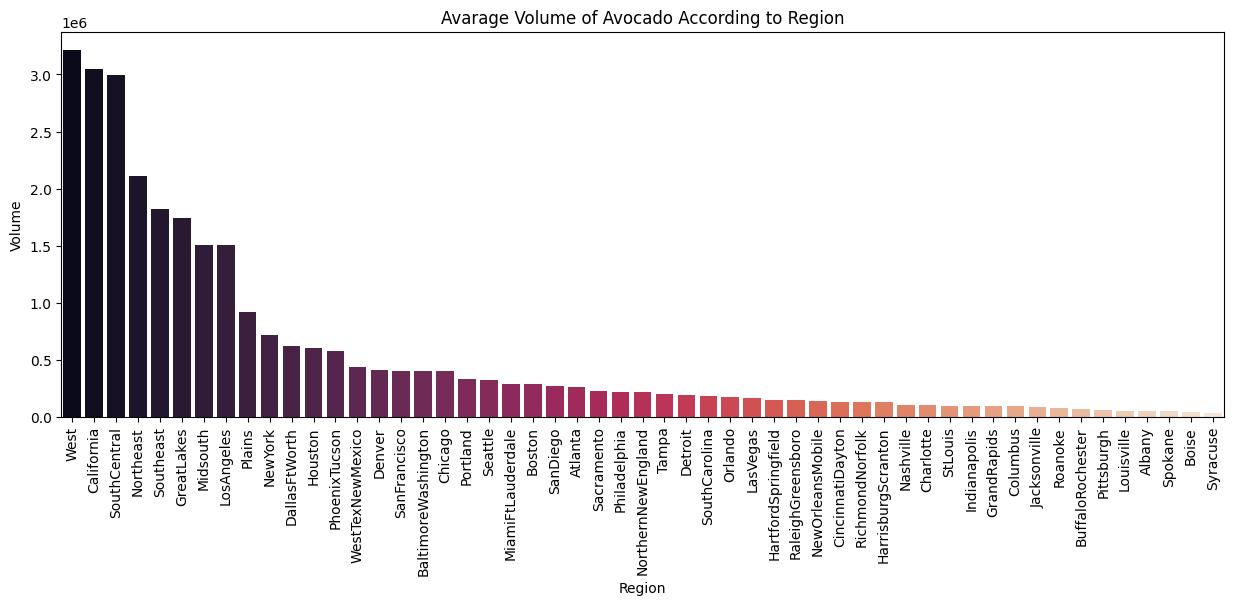

In [15]:
plot(data2,'Region','Volume')

C:\Users\Tharuni\AppData\Local\Temp\ipykernel_8716\1862861028.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=data.column1,y=data.column2,palette='rocket')


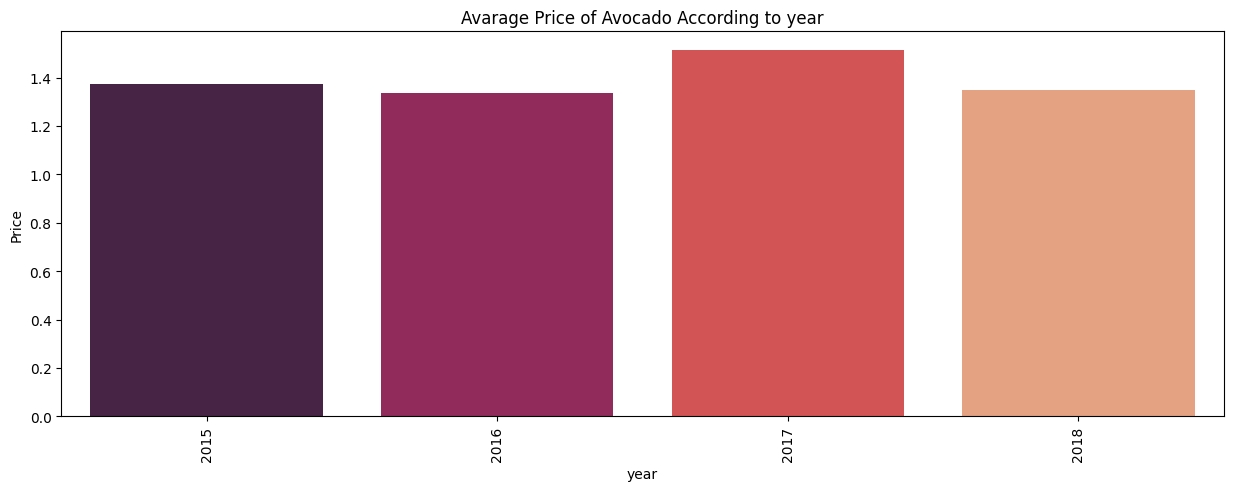

In [16]:
# What is the average avocado prices in each year?
data3= get_avarage_between_two_columns(df, 'year','AveragePrice')
plot(data3,'year','Price')

C:\Users\Tharuni\AppData\Local\Temp\ipykernel_8716\1862861028.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=data.column1,y=data.column2,palette='rocket')


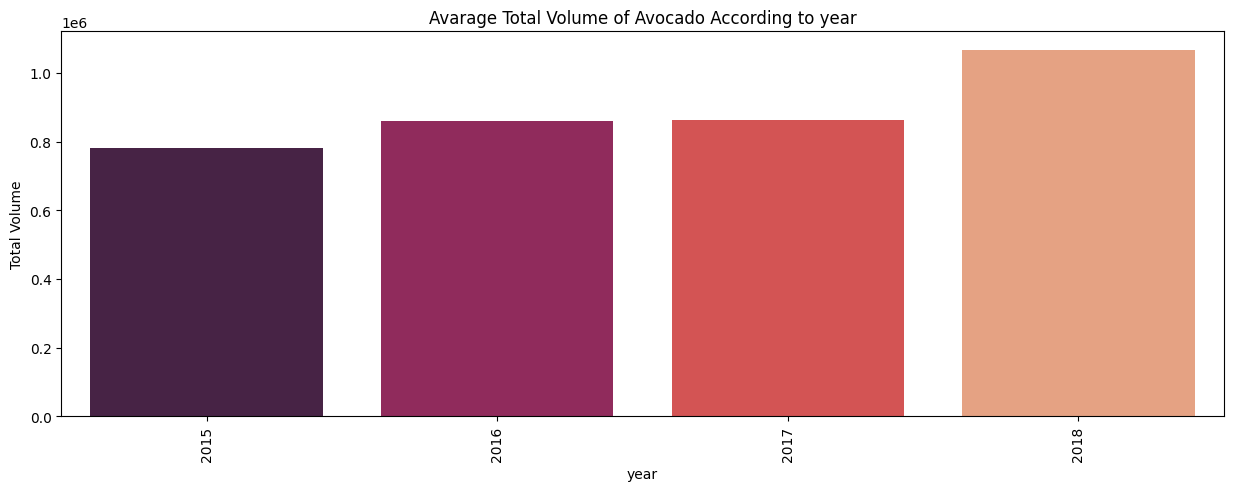

In [17]:
# What is the average avocado volume in each year?
data4 = get_avarage_between_two_columns(df,'year','Total Volume')
plot(data4,'year','Total Volume')

Data Modeling

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AveragePrice  18249 non-null  float64
 1   Total Volume  18249 non-null  float64
 2   Total Bags    18249 non-null  float64
 3   Small Bags    18249 non-null  float64
 4   Large Bags    18249 non-null  float64
 5   XLarge Bags   18249 non-null  float64
 6   type          18249 non-null  object 
 7   year          18249 non-null  int64  
 8   region        18249 non-null  object 
dtypes: float64(6), int64(1), object(2)
memory usage: 1.3+ MB


In [19]:
# Changing some column types to categories
df['region'] = df['region'].astype('category')
df['region'] = df['region'].cat.codes

df['type'] = df['type'].astype('category')
df['type'] = df['type'].cat.codes

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AveragePrice  18249 non-null  float64
 1   Total Volume  18249 non-null  float64
 2   Total Bags    18249 non-null  float64
 3   Small Bags    18249 non-null  float64
 4   Large Bags    18249 non-null  float64
 5   XLarge Bags   18249 non-null  float64
 6   type          18249 non-null  int8   
 7   year          18249 non-null  int64  
 8   region        18249 non-null  int8   
dtypes: float64(6), int64(1), int8(2)
memory usage: 1.0 MB


In [21]:
df.head(5)

,AveragePrice,Total Volume,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,1.33,64236.62,8696.87,8603.62,93.25,0.0,0,2015,0
1,1.35,54876.98,9505.56,9408.07,97.49,0.0,0,2015,0
2,0.93,118220.22,8145.35,8042.21,103.14,0.0,0,2015,0
3,1.08,78992.15,5811.16,5677.40,133.76,0.0,0,2015,0
4,1.28,51039.60,6183.95,5986.26,197.69,0.0,0,2015,0


In [22]:
# split data into x and y
x = df.drop(['AveragePrice'],axis=1)
y = df['AveragePrice']

In [23]:
# split the data into training and testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=1)

In [24]:
print("train_set:",x_train.shape,'-',y_train.shape[0],'samples')
print("test_Set:",x_test.shape,'-',y_test.shape[0],'samples')

train_set: (12774, 8) - 12774 samples
test_Set: (5475, 8) - 5475 samples


In [26]:
# build and fit the model
model = LinearRegression(StandardScaler=True)
model.fit(x_train,y_train)

TypeError: LinearRegression.__init__() got an unexpected keyword argument 'StandardScaler'

In [ ]:
# since this is newer version so we need to import pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline # keeps preprocessinf model together and prevents dataleakage
model = Pipeline([
    ('scaler',StandardScaler()),
    ('regressor',LinearRegression())
])
model.fit(x_train,y_train)

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [31]:
# Evaluate the results 
test_pre = model.predict(x_test)
test_score = r2_score(y_test,test_pre)
print("accuracy of testing dataset", test_score * 100)

accuracy of testing dataset 38.87220346793981


In [32]:
# prediction and calculate the accuracy for the testing dataset
train_pre = model.predict(x_train)
train_score = r2_score(y_train,train_pre)
print("accuracy of training dataset:",train_score * 100)

accuracy of training dataset: 39.60933882374383


The model doesn't work well with this dataset, In order to the avocado prices were near together